# BAB 4 — TAHAP 5: Evaluasi Kinerja Kuantitatif Model AttentiveSkel-3D pada Test Set

Notebook ini menghasilkan **bukti kuantitatif** kinerja model final `AttentiveSkel3D` pada data uji (test set) yang **tidak pernah dilihat selama pelatihan**. Evaluasi ini merupakan penilaian objektif yang akan dilaporkan dalam Sidang Skripsi.

## Metrik yang Dihitung

| Metrik | Keterangan |
|---|---|
| **Accuracy** | Proporsi prediksi benar dari seluruh sampel uji |
| **Precision** | Dari semua yang diprediksi suatu kelas, berapa yang benar |
| **Recall** | Dari semua yang sebenarnya suatu kelas, berapa yang terdeteksi |
| **F1-Score** | Harmonik mean Precision & Recall — metrik utama untuk data tidak seimbang |
| **Confusion Matrix** | Visualisasi distribusi prediksi benar/salah per kelas |

## Konfigurasi Evaluasi

| Parameter | Nilai |
|---|---|
| Model | `AttentiveSkel3D_Final.pth` — model terbaik Skenario 2 |
| Data | Test set — 15% dari total dataset (tidak digunakan saat training/validasi) |
| Device | CUDA / CPU (otomatis) |
| Label kelas | `0` = Gerakan Benar, `1` = Gerakan Salah |

> Evaluasi dilakukan dalam mode `torch.no_grad()` dan `model.eval()` untuk menonaktifkan Dropout dan memastikan BatchNorm menggunakan statistik inferensi.

In [5]:
# ============================================================
# Cell 2: Import library yang dibutuhkan
# ============================================================
import sys
from pathlib import Path

# Tambahkan root proyek ke sys.path agar modul src/ dapat diimport
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

# Metrik evaluasi dari scikit-learn
from sklearn.metrics import confusion_matrix, classification_report

# Modul proyek
from src.data.dataset import create_dataloaders
from src.models.model_3dcnn import AttentiveSkel3D

print("[INFO] Import berhasil.")
print(f"[INFO] PyTorch  : {torch.__version__}")
print(f"[INFO] Seaborn  : {sns.__version__}")

[INFO] Import berhasil.
[INFO] PyTorch  : 2.5.1
[INFO] Seaborn  : 0.13.2


In [6]:
# ============================================================
# Cell 3: Setup device dan muat dataset (ambil test_loader)
# ============================================================

# Konfigurasi device: gunakan GPU jika tersedia, fallback ke CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"[INFO] Device   : {device}")
if device.type == "cuda":
    print(f"[INFO] GPU      : {torch.cuda.get_device_name(0)}")

# Path dataset dan model
MANIFEST_PATH = PROJECT_ROOT / "data" / "processed" / "dataset_manifest.csv"
MODEL_PATH    = PROJECT_ROOT / "models" / "saved_models" / "AttentiveSkel3D_Final.pth"
SAVE_DIR      = PROJECT_ROOT / "models" / "saved_models"

# Muat dataset dengan split yang sama persis dengan saat pelatihan.
# random_seed=42 dan rasio yang identik menjamin test_loader berisi
# sampel yang TIDAK pernah terlihat model selama training maupun validasi.
train_loader, val_loader, test_loader = create_dataloaders(
    csv_file    = MANIFEST_PATH,
    batch_size  = 16,
    train_ratio = 0.70,
    val_ratio   = 0.15,
    num_workers = 0,       # 0 di Windows untuk menghindari masalah multiprocessing
    random_seed = 42,
)

n_test = len(test_loader.dataset)
print(f"\n[INFO] Ukuran test set    : {n_test} sampel")
print(f"[INFO] Iterasi test loader: {len(test_loader)} batch")
print(f"[INFO] Path model         : {MODEL_PATH}")

[INFO] Device   : cuda
[INFO] GPU      : NVIDIA GeForce RTX 3060 Ti
Dataset split selesai (seed=42):
  Train  :  340 sampel → 21 batch
  Val    :   73 sampel → 5 batch
  Test   :   74 sampel → 5 batch

[INFO] Ukuran test set    : 74 sampel
[INFO] Iterasi test loader: 5 batch
[INFO] Path model         : D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\models\saved_models\AttentiveSkel3D_Final.pth


In [7]:

# ============================================================
# Cell 4: Inisialisasi model dan muat bobot tersimpan
# ============================================================

# Bangun ulang arsitektur model (struktur harus identik dengan saat pelatihan)
model = AttentiveSkel3D(num_classes=2).to(device)

# Muat checkpoint dari file .pth
# weights_only=True: praktik keamanan terbaik — mencegah eksekusi kode arbitrer
#                    saat memuat file pickle yang tidak dipercaya.
checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=True)

# Checkpoint bisa berupa bare state_dict atau dict lengkap yang menyimpan
# state_dict di bawah kunci "model_state_dict".
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
else:
    state_dict = checkpoint

model.load_state_dict(state_dict)

# Wajib: set ke mode evaluasi sebelum inferensi
#   - Dropout dinonaktifkan (tidak ada penghapusan neuron acak)
#   - BatchNorm menggunakan statistik running mean/var (bukan mini-batch)
model.eval()

print(f"[INFO] Model              : AttentiveSkel-3D (Arsitektur Penuh)")
print(f"[INFO] Bobot dimuat dari  : {MODEL_PATH.name}")
print(f"[INFO] Mode               : eval() — siap inferensi")


[INFO] Model              : AttentiveSkel-3D (Arsitektur Penuh)
[INFO] Bobot dimuat dari  : AttentiveSkel3D_Final.pth
[INFO] Mode               : eval() — siap inferensi


In [8]:
# ============================================================
# Cell 5: Loop inferensi pada test set
# ============================================================
# Kumpulkan semua label aktual dan prediksi model menjadi array NumPy
# untuk diteruskan ke fungsi metrik scikit-learn.

all_true_labels  = []   # Label ground-truth dari dataset
all_pred_labels  = []   # Prediksi kelas dari model (argmax logit)

# torch.no_grad(): nonaktifkan perhitungan gradient → hemat memori & lebih cepat
with torch.no_grad():
    for batch_data, batch_labels in test_loader:
        # Pindahkan ke device yang sesuai
        batch_data   = batch_data.to(device)    # (B, 64, 33, 3)
        batch_labels = batch_labels.to(device)  # (B,)

        # Forward pass: dapatkan logit mentah
        logits = model(batch_data)              # (B, num_classes)

        # Ambil indeks kelas dengan probabilitas tertinggi sebagai prediksi
        preds = logits.argmax(dim=1)            # (B,)

        # Pindahkan ke CPU dan konversi ke NumPy untuk kompatibilitas scikit-learn
        all_true_labels.extend(batch_labels.cpu().numpy())
        all_pred_labels.extend(preds.cpu().numpy())

# Konversi list ke array NumPy
all_true_labels = np.array(all_true_labels)
all_pred_labels = np.array(all_pred_labels)

# Hitung akurasi keseluruhan secara manual sebagai sanity check
manual_acc = (all_true_labels == all_pred_labels).mean() * 100
print(f"[INFO] Inferensi selesai pada {len(all_true_labels)} sampel test.")
print(f"[INFO] Akurasi keseluruhan (manual) : {manual_acc:.2f}%")

[INFO] Inferensi selesai pada 74 sampel test.
[INFO] Akurasi keseluruhan (manual) : 97.30%


In [9]:
# ============================================================
# Cell 6: Classification Report (Accuracy, Precision, Recall, F1-Score)
# ============================================================
# scikit-learn menghasilkan laporan lengkap per kelas beserta rata-rata makro.
# Nama kelas disesuaikan dengan domain: 0 = Gerakan Benar, 1 = Gerakan Salah.

CLASS_NAMES = ["Gerakan Benar (0)", "Gerakan Salah (1)"]

report = classification_report(
    all_true_labels,
    all_pred_labels,
    target_names = CLASS_NAMES,
    digits       = 4,    # 4 desimal untuk presisi laporan
)

print(f"\n{'='*65}")
print(f"  LAPORAN KLASIFIKASI — AttentiveSkel-3D pada Test Set")
print(f"{'='*65}")
print(report)
print(f"{'='*65}")


  LAPORAN KLASIFIKASI — AttentiveSkel-3D pada Test Set
                   precision    recall  f1-score   support

Gerakan Benar (0)     0.9804    0.9804    0.9804        51
Gerakan Salah (1)     0.9565    0.9565    0.9565        23

         accuracy                         0.9730        74
        macro avg     0.9685    0.9685    0.9685        74
     weighted avg     0.9730    0.9730    0.9730        74



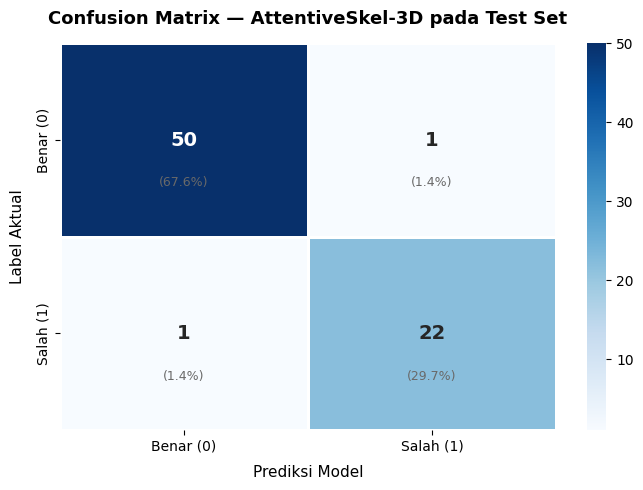


  RINGKASAN CONFUSION MATRIX
  True Negative  (TN):   50  — Gerakan Benar diprediksi Benar
  False Positive (FP):    1  — Gerakan Benar diprediksi Salah
  False Negative (FN):    1  — Gerakan Salah diprediksi Benar
  True Positive  (TP):   22  — Gerakan Salah diprediksi Salah
  Gambar tersimpan : D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\models\saved_models\confusion_matrix_final.png


In [10]:
# ============================================================
# Cell 7: Visualisasi Confusion Matrix
# ============================================================
# Confusion Matrix menampilkan distribusi prediksi model secara visual:
#   - Sumbu Y (baris) : Label Aktual (ground-truth dari dataset)
#   - Sumbu X (kolom) : Prediksi Model (output argmax)
#   - Sel diagonal    : Prediksi BENAR (True Positive & True Negative)
#   - Sel off-diagonal: Prediksi SALAH (False Positive & False Negative)

LABEL_NAMES = ["Benar (0)", "Salah (1)"]

# Hitung confusion matrix dari prediksi yang sudah dikumpulkan di Cell 5
cm = confusion_matrix(all_true_labels, all_pred_labels)

# ── Buat figure ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    cm,
    annot       = True,         # Tampilkan angka di setiap sel
    fmt         = "d",          # Format integer (bukan float)
    cmap        = "Blues",      # Palet warna biru elegan
    linewidths  = 0.8,          # Garis pemisah antar sel
    linecolor   = "white",
    xticklabels = LABEL_NAMES,  # Label sumbu X (prediksi)
    yticklabels = LABEL_NAMES,  # Label sumbu Y (aktual)
    annot_kws   = {"size": 14, "weight": "bold"},
    ax          = ax,
)

# Anotasi judul dan label sumbu
ax.set_title(
    "Confusion Matrix — AttentiveSkel-3D pada Test Set",
    fontsize=13, fontweight="bold", pad=14,
)
ax.set_xlabel("Prediksi Model", fontsize=11, labelpad=8)
ax.set_ylabel("Label Aktual",   fontsize=11, labelpad=8)
ax.tick_params(axis="both", labelsize=10)

# Tambahkan persentase di bawah angka di setiap sel
total = cm.sum()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        pct = cm[i, j] / total * 100
        ax.text(
            j + 0.5, i + 0.72,
            f"({pct:.1f}%)",
            ha="center", va="center",
            fontsize=9, color="dimgray",
        )

plt.tight_layout()

# Simpan gambar ke folder models/saved_models/
CM_PATH = SAVE_DIR / "confusion_matrix_final.png"
plt.savefig(CM_PATH, dpi=150, bbox_inches="tight")
plt.show()

# ── Ringkasan sel confusion matrix ───────────────────────
tn, fp, fn, tp = cm.ravel()
print(f"\n{'='*55}")
print(f"  RINGKASAN CONFUSION MATRIX")
print(f"{'='*55}")
print(f"  True Negative  (TN): {tn:4d}  — Gerakan Benar diprediksi Benar")
print(f"  False Positive (FP): {fp:4d}  — Gerakan Benar diprediksi Salah")
print(f"  False Negative (FN): {fn:4d}  — Gerakan Salah diprediksi Benar")
print(f"  True Positive  (TP): {tp:4d}  — Gerakan Salah diprediksi Salah")
print(f"{'='*55}")
print(f"  Gambar tersimpan : {CM_PATH}")